In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Dataset paths (relative to notebooks/)
AI_DATASET_DIR = Path("../ai_dataset")
NORMAL_DIR = AI_DATASET_DIR / "ai_normal"
ATTACK_DIR = AI_DATASET_DIR / "ai_attack"
OUTPUT_DIR = Path(".")  # preprocessed splits saved next to notebook

In [3]:
# ── Load ALL data — no downsampling at this stage ─────────────────────────────
# Imbalance between normal and attack is handled later via class weights / SMOTE.
# Downsampling attacks here would throw away 88% of attack data.

def safe_read_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except (pd.errors.EmptyDataError, FileNotFoundError):
        print(f"Warning: {path} is empty or missing, skipping.")
        return pd.DataFrame()

def load_folder(folder: Path, label: int) -> pd.DataFrame:
    """Load all *_essential.csv from folder and tag with label + source filename."""
    dfs = []
    for csv_path in sorted(folder.glob("*_essential.csv")):
        df = safe_read_csv(csv_path)
        if df.empty:
            continue
        df = df.copy()
        df["label"] = label
        df["source"] = csv_path.stem  # filename without extension
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

normal_df = load_folder(NORMAL_DIR, label=0)
attack_df = load_folder(ATTACK_DIR, label=1)

print(f"Normal : {len(normal_df):,} rows from {normal_df['source'].nunique()} files")
print(f"Attack : {len(attack_df):,} rows from {attack_df['source'].nunique()} types")
print(f"Imbalance ratio  : 1 : {len(attack_df) / max(len(normal_df), 1):.1f}  (normal : attack)")
print(f"Total raw columns: {normal_df.shape[1]}")

Normal : 2,661 rows from 13 files
Attack : 31,070 rows from 45 types
Imbalance ratio  : 1 : 11.7  (normal : attack)
Total raw columns: 280


/tmp/ipykernel_484953/1716657508.py:7: DtypeWarning: Columns (0: e212_imsi_value, 1: gsm_a_dtap_autn_value, 2: gsm_a_dtap_autn_mac_value, 3: gsm_a_dtap_autn_sqn_xor_ak_value, 4: gsm_a_dtap_rand_value, 5: lte-rrc_c_rnti_value, 6: lte-rrc_cn_domain_value, 7: lte-rrc_nexthopchainingcount_value, 8: lte-rrc_pagingrecordlist_value, 9: lte-rrc_physcellid_value, 10: lte-rrc_reestablishmentcause_value, 11: lte-rrc_shortmac_i_value) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


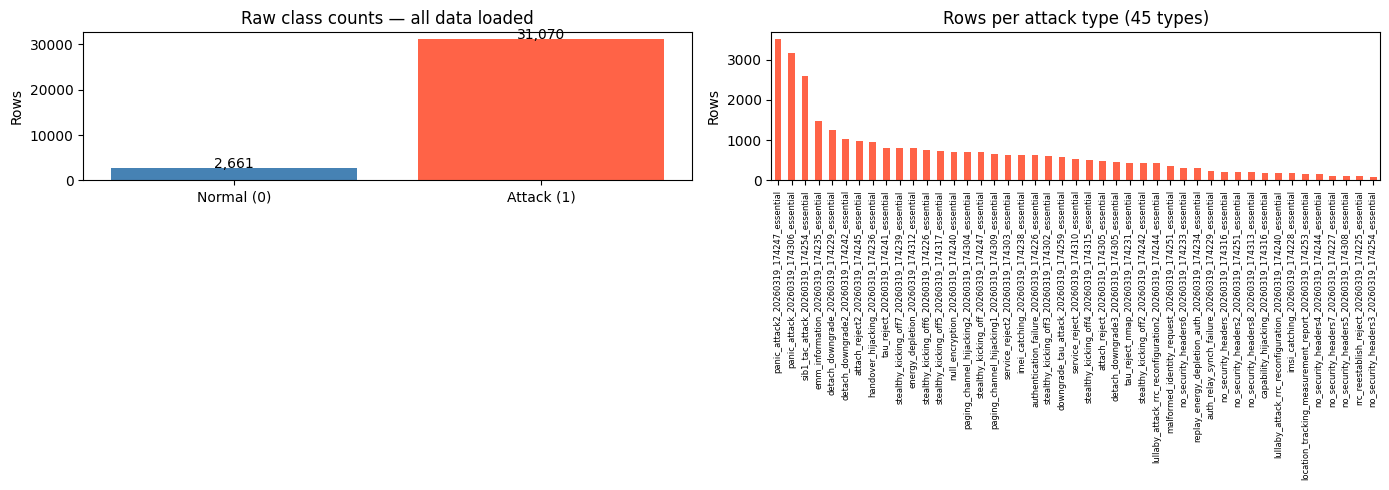


Normal files — row counts:
source
normal_data9_20260319_174219_essential     500
normal_data12_20260319_174218_essential    478
normal_data10_20260319_174223_essential    427
normal_data13_20260319_174222_essential    330
normal_data11_20260319_174222_essential    326
normal_data6_20260319_174224_essential     110
normal_data2_20260319_174220_essential      96
normal_data8_20260319_174224_essential      86
normal_data7_20260319_174221_essential      76
normal_data_20260319_174223_essential       67
normal_data4_20260319_174225_essential      64
normal_data3_20260319_174218_essential      60
normal_data5_20260319_174220_essential      41


In [4]:
# ── Section 2: EDA — Class Imbalance Overview ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall class counts
counts = [len(normal_df), len(attack_df)]
bars = axes[0].bar(["Normal (0)", "Attack (1)"], counts, color=["steelblue", "tomato"])
axes[0].set_title("Raw class counts — all data loaded")
axes[0].set_ylabel("Rows")
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 50, f"{v:,}", ha="center", fontsize=10)

# Right: rows per attack source file
attack_counts = attack_df.groupby("source").size().sort_values(ascending=False)
attack_counts.plot(kind="bar", ax=axes[1], color="tomato")
axes[1].set_title(f"Rows per attack type ({attack_df['source'].nunique()} types)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", labelsize=6, rotation=90)
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nNormal files — row counts:")
print(normal_df.groupby("source").size().sort_values(ascending=False).to_string())

Total _value columns : 91
  > 50% missing :   73  (80.2%)
  > 80% missing :   64  (70.3%)
  > 90% missing :   59  (64.8%)
  > 95% missing :   58  (63.7%)
  > 99% missing :   56  (61.5%)

Columns kept (≤95% missing) : 33


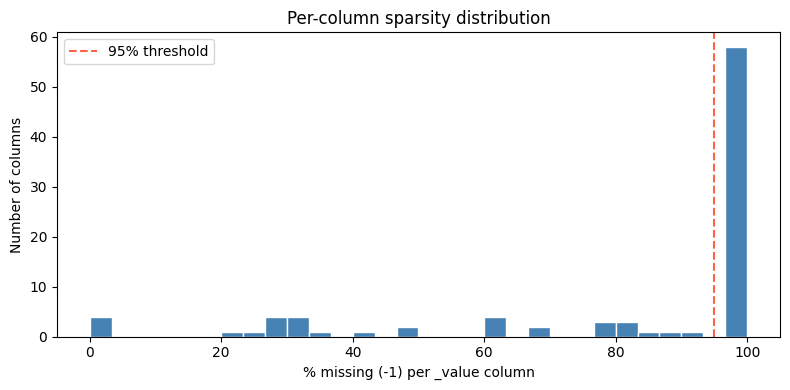

In [5]:
# ── Feature sparsity analysis ──────────────────────────────────────────────────
# Identify value columns with >95% missing data (-1 sentinel) across combined dataset.
# These columns carry no useful signal and are dropped.

raw_combined = pd.concat([normal_df, attack_df], ignore_index=True)

value_cols = [c for c in raw_combined.columns if c.endswith("_value")]
missing_pct = (raw_combined[value_cols] == -1).mean().sort_values()

print(f"Total _value columns : {len(value_cols)}")
for t in [0.50, 0.80, 0.90, 0.95, 0.99]:
    n = (missing_pct > t).sum()
    print(f"  > {t*100:.0f}% missing : {n:4d}  ({n / len(value_cols) * 100:.1f}%)")

SPARSITY_THRESHOLD = 0.95
kept_value_cols_eda = missing_pct[missing_pct <= SPARSITY_THRESHOLD].index.tolist()
print(f"\nColumns kept (≤{SPARSITY_THRESHOLD*100:.0f}% missing) : {len(kept_value_cols_eda)}")

plt.figure(figsize=(8, 4))
plt.hist(missing_pct * 100, bins=30, color="steelblue", edgecolor="white")
plt.axvline(SPARSITY_THRESHOLD * 100, color="tomato", linestyle="--",
            label=f"{SPARSITY_THRESHOLD*100:.0f}% threshold")
plt.xlabel("% missing (-1) per _value column")
plt.ylabel("Number of columns")
plt.title("Per-column sparsity distribution")
plt.legend()
plt.tight_layout()
plt.savefig("feature_sparsity.png", dpi=100, bbox_inches="tight")
plt.show()

In [6]:
# ── Per-class feature means for kept columns (discriminative signal check) ─────
rows = []
for col in kept_value_cols_eda:
    v_n = raw_combined.loc[raw_combined["label"] == 0, col].replace(-1, np.nan).dropna()
    v_a = raw_combined.loc[raw_combined["label"] == 1, col].replace(-1, np.nan).dropna()
    rows.append({
        "feature"     : col,
        "missing_%"   : round(missing_pct[col] * 100, 1),
        "normal_mean" : round(v_n.mean(), 3) if len(v_n) else np.nan,
        "attack_mean" : round(v_a.mean(), 3) if len(v_a) else np.nan,
        "normal_std"  : round(v_n.std(),  3) if len(v_n) else np.nan,
        "attack_std"  : round(v_a.std(),  3) if len(v_a) else np.nan,
    })

feat_df = pd.DataFrame(rows).set_index("feature")
print(feat_df.to_string())

print("\n── packet_type by class ─────────────────────────────────────────────────")
print(raw_combined.groupby(["label", "packet_type"]).size().unstack(fill_value=0))
print("\n── direction by class ───────────────────────────────────────────────────")
print(raw_combined.groupby(["label", "direction"]).size().unstack(fill_value=0))

TypeError: Cannot perform reduction 'mean' with string dtype

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 3 — Preprocessing Pipeline
# ══════════════════════════════════════════════════════════════════════════════

METADATA_COLS = ["timestamp", "message_index", "info"]

def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    """Drop pure metadata columns; packet_type and direction are kept as signal features."""
    return df.drop(columns=[c for c in METADATA_COLS if c in df.columns], errors="ignore")

normal_clean     = clean_df(normal_df)
attack_all_clean = clean_df(attack_df)

dedup_cols = [c for c in normal_clean.columns if c not in ("source", "label")]

# ── Step 1: Keep all normal rows — no cross-file deduplication ────────────────
# All 2,719 normal rows are already unique within their individual capture files.
# The same network state appearing across multiple sessions is a legitimate
# repeated observation — each capture session is a separate measurement.

normal_dedup = normal_clean.reset_index(drop=True)

print(f"Normal  : {len(normal_clean):,} rows retained (no cross-file dedup)")
print(f"Attack  : {len(attack_all_clean):,} raw rows across {attack_all_clean['source'].nunique()} types")

# ── Step 2: Quota sampling — deduplicate WITHIN each attack type first ─────────
# Within-type dedup removes truly redundant identical rows while preserving
# the characteristic feature patterns of each attack type.
# Cross-type dedup is NOT performed — same features, different attack = valid.

n_normal       = len(normal_dedup)
n_attack_types = attack_all_clean["source"].nunique()
quota          = max(1, n_normal // n_attack_types)

print(f"\nQuota per attack type : {quota}  (= floor({n_normal} normal / {n_attack_types} types))")

attack_sampled = []
for src, grp in attack_all_clean.groupby("source"):
    unique_grp = grp.drop_duplicates(subset=dedup_cols)
    n_take     = min(len(unique_grp), quota)
    sample     = unique_grp.sample(n=n_take, random_state=42) if len(unique_grp) > n_take else unique_grp
    attack_sampled.append(sample)

attack_clean = pd.concat(attack_sampled, ignore_index=True)

print(f"\nAttack after sampling : {len(attack_clean):,} rows  ({attack_clean['source'].nunique()} types retained)")
print(f"Normal                : {len(normal_dedup):,} rows")

# ── Step 3: Combine ────────────────────────────────────────────────────────────
dataset = pd.concat([normal_dedup, attack_clean], axis=0, ignore_index=True).reset_index(drop=True)

print(f"\nCombined : {len(dataset):,} total")
print(f"Normal   : {(dataset['label'] == 0).sum():,}")
print(f"Attack   : {(dataset['label'] == 1).sum():,}")

Normal  : 2,719 rows retained (no cross-file dedup)
Attack  : 31,209 raw rows across 45 types

Quota per attack type : 60  (= floor(2719 normal / 45 types))

Attack after sampling : 2,538 rows  (45 types retained)
Normal                : 2,719 rows

Combined : 5,257 total
Normal   : 2,719
Attack   : 2,538


In [ ]:
# ── Use all _value columns — no sparsity filtering ────────────────────────────
# All columns are kept regardless of missing rate.
# Presence flags (added in the next cell) already encode whether a field is
# present or absent, so high-sparsity columns still carry signal via their flag.

all_value_cols  = [c for c in dataset.columns if c.endswith("_value") and c != "label"]
keep_value_cols = all_value_cols

missing_pct_ds = (dataset[all_value_cols] == -1).mean()
print(f"Total _value cols : {len(keep_value_cols)}")
print(f"Sparsity summary  : min={missing_pct_ds.min():.2f}  median={missing_pct_ds.median():.2f}  max={missing_pct_ds.max():.2f}")

Total _value cols : 376
Sparsity summary  : min=0.52  median=0.98  max=1.00


In [ ]:
# ── Presence indicators + imputation ──────────────────────────────────────────
presence_df = (dataset[keep_value_cols] != -1).astype(np.int8)
presence_df.columns = [f"{c}_present" for c in keep_value_cols]

# Value cols with -1 sentinel replaced by column median
value_df = dataset[keep_value_cols].copy()
for col in keep_value_cols:
    value_df[col] = value_df[col].replace(-1, np.nan)
    med = value_df[col].median()
    value_df[col] = value_df[col].fillna(0 if pd.isna(med) else med)

# ── One-hot encode categorical signal columns ──────────────────────────────────
signal_cols_raw = [c for c in ["packet_type", "direction"] if c in dataset.columns]
if signal_cols_raw:
    sig_df = dataset[signal_cols_raw].copy()
    for col in signal_cols_raw:
        sig_df[col] = sig_df[col].replace(-1, np.nan)
        mode_val = sig_df[col].mode()
        sig_df[col] = sig_df[col].fillna(mode_val.iloc[0] if len(mode_val) else 0)
    ohe_df   = pd.get_dummies(sig_df, columns=signal_cols_raw, dtype=np.int8)
    ohe_cols = list(ohe_df.columns)
else:
    ohe_df   = pd.DataFrame(index=dataset.index)
    ohe_cols = []

# ── Protocol-semantic aggregate features ──────────────────────────────────────
pres_cols = list(presence_df.columns)
nas_pres  = [c for c in pres_cols if c.startswith("nas-eps_")]
rrc_pres  = [c for c in pres_cols if c.startswith("lte-rrc_")]
eea_val   = [c for c in keep_value_cols if "eea" in c.lower()]
eia_val   = [c for c in keep_value_cols if "eia" in c.lower()]

agg_parts = {}
if nas_pres:
    agg_parts["nas_field_count"] = presence_df[nas_pres].sum(axis=1).astype(np.int16)
if rrc_pres:
    agg_parts["rrc_field_count"] = presence_df[rrc_pres].sum(axis=1).astype(np.int16)
if eea_val:
    agg_parts["eea_cap_count"]   = value_df[eea_val].sum(axis=1).astype(np.int16)
if eia_val:
    agg_parts["eia_cap_count"]   = value_df[eia_val].sum(axis=1).astype(np.int16)

agg_df   = pd.DataFrame(agg_parts, index=dataset.index)
agg_cols = list(agg_df.columns)

# ── Assemble final feature matrix in one concat ────────────────────────────────
X_df = pd.concat([value_df, presence_df, ohe_df, agg_df], axis=1).copy()

y            = dataset["label"].values
sources      = dataset["source"].values
feature_cols = list(X_df.columns)

print(f"Feature matrix : {X_df.shape}")
print(f"  _value cols        : {len(keep_value_cols)}")
print(f"  presence flags     : {len(keep_value_cols)}")
print(f"  OHE signal cols    : {len(ohe_cols)}  →  {ohe_cols}")
print(f"  aggregate features : {len(agg_cols)}  →  {agg_cols}")
print(f"Class counts   : normal={int((y == 0).sum()):,}, attack={int((y == 1).sum()):,}")

Feature matrix : (5257, 762)
  _value cols        : 376
  presence flags     : 376
  OHE signal cols    : 6  →  ['packet_type_1', 'packet_type_2', 'packet_type_3', 'packet_type_4', 'direction_0.0', 'direction_1.0']
  aggregate features : 4  →  ['nas_field_count', 'rrc_field_count', 'eea_cap_count', 'eia_cap_count']
Class counts   : normal=2,719, attack=2,538


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 4 — Train / Test Split  (80 / 20)
# ──────────────────────────────────────────────────────────────────────────────
# Stratified by (label + source) — guarantees every attack type and every
# normal file has samples in the training set.
# Sources with only 1 sample are forced entirely into training.
# ══════════════════════════════════════════════════════════════════════════════

from collections import Counter

X = X_df.values

# Combined key: class label + source file
strat_key  = np.array([f"{int(l)}|{s}" for l, s in zip(y, sources)])
key_counts = Counter(strat_key)

# Samples whose key appears only once cannot be split — force them to training
can_split  = np.array([key_counts[k] >= 2 for k in strat_key])
n_forced   = int((~can_split).sum())

X_split    = X[can_split];        y_split   = y[can_split]
src_split  = sources[can_split];  sk_split  = strat_key[can_split]
X_force    = X[~can_split];       y_force   = y[~can_split]
src_force  = sources[~can_split]

X_train, X_test, y_train, y_test, src_train, src_test = train_test_split(
    X_split, y_split, src_split,
    test_size=0.20,
    stratify=sk_split,
    random_state=42
)

# Append singleton samples to training
if n_forced > 0:
    X_train   = np.vstack([X_train, X_force])
    y_train   = np.concatenate([y_train, y_force])
    src_train = np.concatenate([src_train, src_force])

def split_summary(name, y_s, src_s):
    n = int((y_s == 0).sum()); a = int((y_s == 1).sum()); total = len(y_s)
    print(f"  {name:5s} : {total:5,} rows — normal={n:,} ({n/total*100:.1f}%)  "
          f"attack={a:,} ({a/total*100:.1f}%)  |  {len(set(src_s))} unique sources")

print("Split summary (source-stratified, 80/20):")
split_summary("Train", y_train, src_train)
split_summary("Test ", y_test,  src_test)
print(f"\n  Singleton samples forced to train : {n_forced}")
print(f"  Train sources : {sorted(set(src_train))}")
print(f"  Test  sources : {sorted(set(src_test))}")

Split summary (source-stratified, 80/20):
  Train : 4,205 rows — normal=2,174 (51.7%)  attack=2,031 (48.3%)  |  58 unique sources
  Test  : 1,052 rows — normal=545 (51.8%)  attack=507 (48.2%)  |  58 unique sources

  Singleton samples forced to train : 0
  Train sources : ['attach_reject2_20260313_172431_essential', 'attach_reject_20260313_172337_essential', 'auth_relay_synch_failure_20260313_172237_essential', 'authentication_failure_20260313_172305_essential', 'capability_hijacking_20260313_172438_essential', 'detach_downgrade2_20260313_172331_essential', 'detach_downgrade3_20260313_172405_essential', 'detach_downgrade_20260313_172300_essential', 'downgrade_tau_attack_20260313_172229_essential', 'emm_information_20260313_172347_essential', 'energy_depletion_20260313_172256_essential', 'handover_hijacking_20260313_172441_essential', 'imei_catching_20260313_172445_essential', 'imsi_catching_20260313_172327_essential', 'location_tracking_measurement_report_20260313_172434_essential', 'l

In [ ]:
# ── Class weights — computed from training split only ─────────────────────────
# Classes are balanced so weights will be close to 1.0.
# Still computed and saved so model notebooks have a consistent loading path.

class_weights_arr = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
cw_dict = {0: float(class_weights_arr[0]), 1: float(class_weights_arr[1])}
print(f"Class weights  : normal={cw_dict[0]:.4f}, attack={cw_dict[1]:.4f}")
print("(values near 1.0 confirm classes are balanced)")

Class weights  : normal=0.9671, attack=1.0352
(values near 1.0 confirm classes are balanced)


In [ ]:
# ── Save train / test splits to CSV ───────────────────────────────────────────

def arrays_to_df(X_arr, y_arr, src_arr=None):
    df = pd.DataFrame(X_arr, columns=feature_cols)
    df["label"] = y_arr
    if src_arr is not None:
        df["source"] = src_arr
    return df

train_df = arrays_to_df(X_train, y_train, src_train)
test_df  = arrays_to_df(X_test,  y_test,  src_test)

# Full preprocessed + balanced dataset (pre-split, for reference)
full_df = pd.DataFrame(X, columns=feature_cols)
full_df["label"]  = y
full_df["source"] = sources

train_df.to_csv(OUTPUT_DIR / "fbs_train.csv",        index=False)
test_df.to_csv( OUTPUT_DIR / "fbs_test.csv",         index=False)
full_df.to_csv( OUTPUT_DIR / "fbs_preprocessed.csv", index=False)

cw_path = OUTPUT_DIR / "fbs_class_weights.json"
with open(cw_path, "w") as f:
    json.dump(cw_dict, f, indent=2)

print("Saved preprocessed splits:")
print(f"  fbs_train.csv        : {len(train_df):,} rows × {len(feature_cols)} features")
print(f"  fbs_test.csv         : {len(test_df):,} rows × {len(feature_cols)} features")
print(f"  fbs_preprocessed.csv : {len(full_df):,} rows × {len(feature_cols)} features  (full reference)")
print(f"  fbs_class_weights.json : {cw_dict}")

Saved preprocessed splits:
  fbs_train.csv        : 4,205 rows × 762 features
  fbs_test.csv         : 1,052 rows × 762 features
  fbs_preprocessed.csv : 5,257 rows × 762 features  (full reference)
  fbs_class_weights.json : {0: 0.9671113155473781, 1: 1.035204332840965}


In [ ]:
# ── Preprocessing summary ──────────────────────────────────────────────────────
print("=" * 65)
print("PREPROCESSING SUMMARY")
print("=" * 65)
print(f"Raw data             : {len(normal_df):,} normal + {len(attack_df):,} attack")
print(f"After balancing      : {len(normal_dedup):,} normal + {len(attack_clean):,} attack")
print(f"  quota per type     : {quota} rows × {n_attack_types} types")
print(f"Features used        : {len(feature_cols)}")
print(f"  _value columns     : {len(keep_value_cols)}")
print(f"  presence flags     : {len(keep_value_cols)}")
print(f"  OHE signal cols    : {len(ohe_cols)}")
print()
print(f"Train  : {len(train_df):,} rows  (80%)")
print(f"Test   : {len(test_df):,} rows  (20%)")
print()
print(f"Class weights (≈1.0 — classes are balanced): {cw_dict}")

PREPROCESSING SUMMARY
Raw data             : 2,719 normal + 31,209 attack
After balancing      : 2,719 normal + 2,538 attack
  quota per type     : 60 rows × 45 types
Features used        : 762
  _value columns     : 376
  presence flags     : 376
  OHE signal cols    : 6

Train  : 4,205 rows  (80%)
Test   : 1,052 rows  (20%)

Class weights (≈1.0 — classes are balanced): {0: 0.9671113155473781, 1: 1.035204332840965}


In [ ]:
# ── Balancing strategy summary ─────────────────────────────────────────────────
# Normal data  : all 2,719 rows kept (no cross-file dedup).
#   Repeated protocol states across sessions = legitimate repeated observations.
#
# Attack data  : sampled from raw rows (no within-type dedup), quota per type:
#   quota = floor(n_normal / n_attack_types)
#         = floor(2719 / 45)
#         = 60 rows per type
#
#   Repeated packets within an attack type ARE the attack signature.
#   e.g. panic_attack: 3,160 near-identical flood packets → 10 unique after dedup
#   → only 6 training samples. Sampling raw gives 60 samples → ~36 training.
#
# Types with fewer than quota raw rows contribute all their available rows.
# All 45 attack types are retained in the final dataset.

print(f"Balancing  : {n_attack_types} types × up to {quota} rows/type = {len(attack_clean):,} attack rows")
print(f"Normal     : {len(normal_dedup):,} rows")
print(f"Ratio      : {len(normal_dedup) / len(attack_clean):.2f} : 1  (normal : attack)")

Balancing  : 45 types × up to 60 rows/type = 2,538 attack rows
Normal     : 2,719 rows
Ratio      : 1.07 : 1  (normal : attack)
